### Importing the libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



import warnings
warnings.filterwarnings("ignore")

#### Loading the data set

In [74]:
import zipfile
import pandas as pd

zip_path = r"C:\Users\User\Desktop\advanced_ml\individual+household+electric+power+consumption.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())   # Shows the files inside

    with z.open("household_power_consumption.txt") as f:
        df = pd.read_csv(
            f,
            sep=";",
            na_values="?",
            low_memory=False
        )

df.head()

['household_power_consumption.txt']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


#### Data pre processing and EDA

In [75]:

df.info()
df.isnull().sum().sort_values(ascending=False) # Checking for missingness

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


Global_active_power      25979
Sub_metering_2           25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_3           25979
Sub_metering_1           25979
Date                         0
Time                         0
dtype: int64

In [76]:
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')


Since the dataset has separate Date and Time columns, combine them

In [77]:
# Setting the date as the index
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [78]:
df.drop(columns=['Date', 'Time'], inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### Missing value treatment

In [79]:

missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)


Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
dtype: float64

In [80]:
numeric_cols = df.select_dtypes(include=np.number).columns
# Interpolate missing values in all numeric columns using the time index.
# This estimates missing observations based on the values before and after them, preserving the temporal pattern of the time series.
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

# Fill any remaining missing values.
# Forward fill (ffill) propagates the previous valid observation forward, while backward fill (bfill) propagates the next valid observation backward.
# This ensures that no missing values remain in the numeric features.
df[numeric_cols] = df[numeric_cols].ffill().bfill()




In [81]:
# Verify that all missing values have been handled.
df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

#### Resampling Data into Hourly Intervals 

Since the original data is recorded every minute, hourly aggregation makes modelling much more efficient

In [82]:
# Resample to hourly averages
df_hourly = df.resample('h').mean()

# Display the first few rows
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


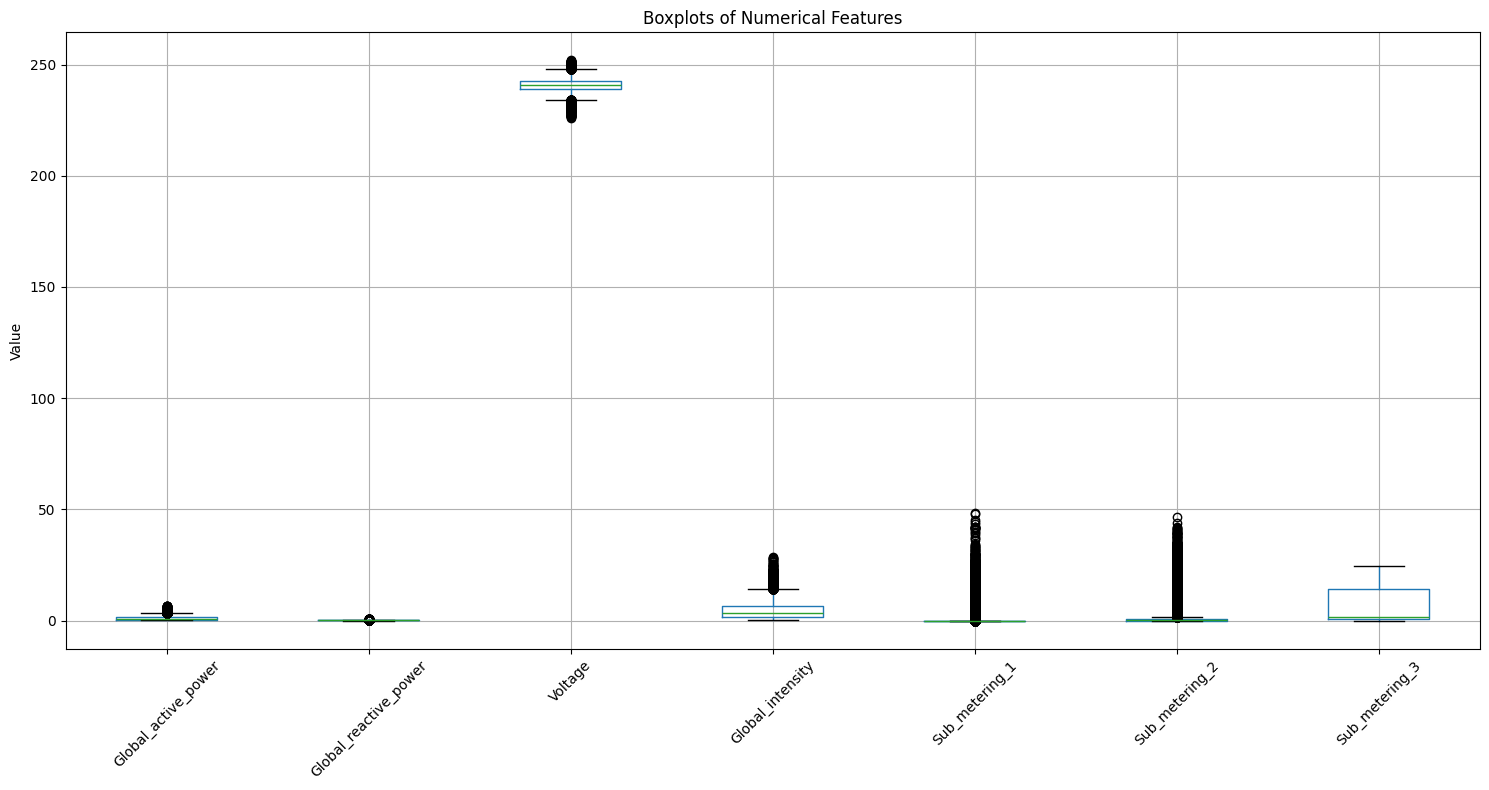

In [83]:
# checking for outliers
# Create boxplots
plt.figure(figsize=(15, 8))
df_hourly[numeric_cols].boxplot(rot=45)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

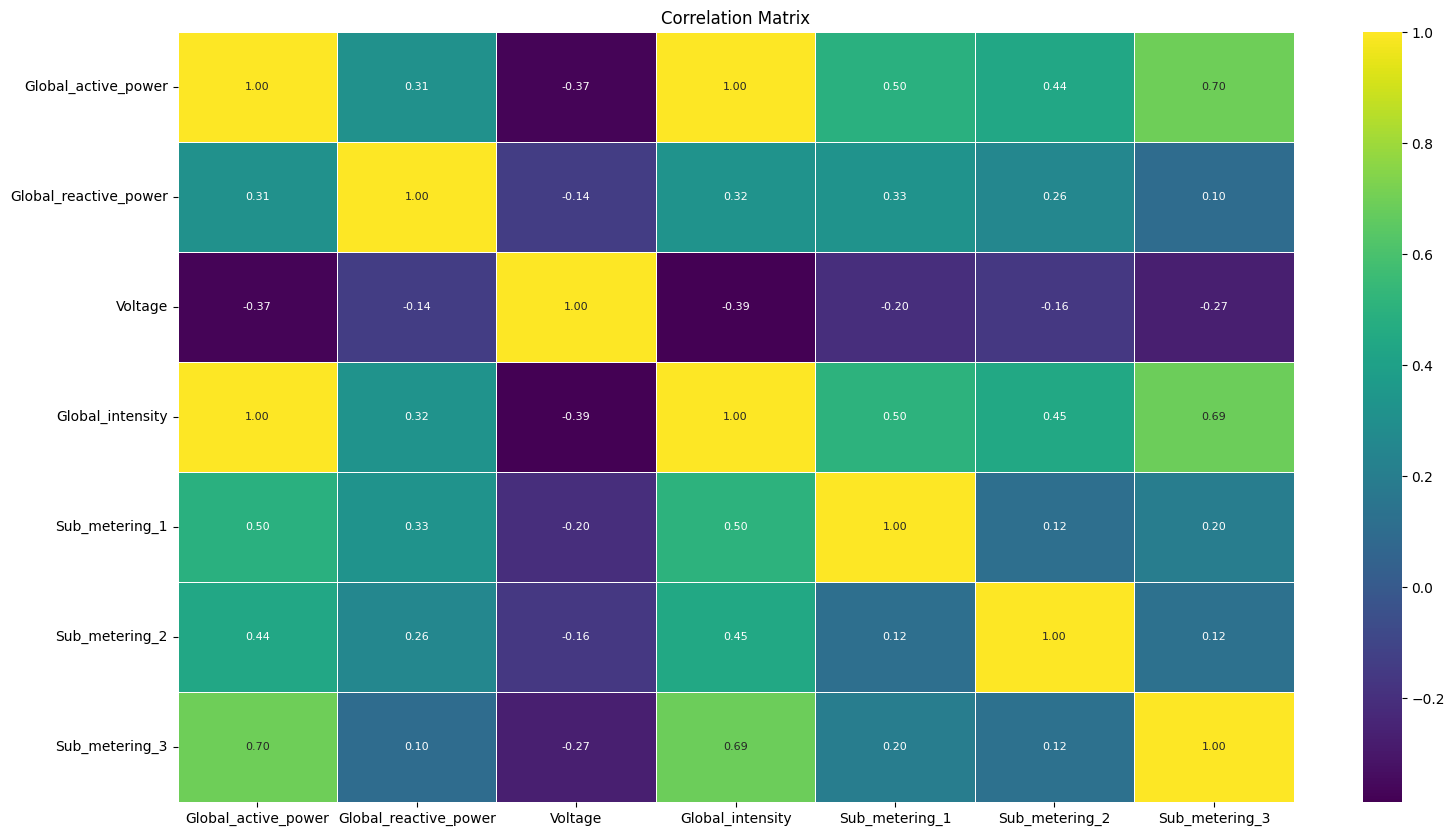

In [84]:
# Compute correlation matrix
corr_matrix = df_hourly[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(18,10))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display 2 decimal places
    cmap="viridis",
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix")
plt.show()

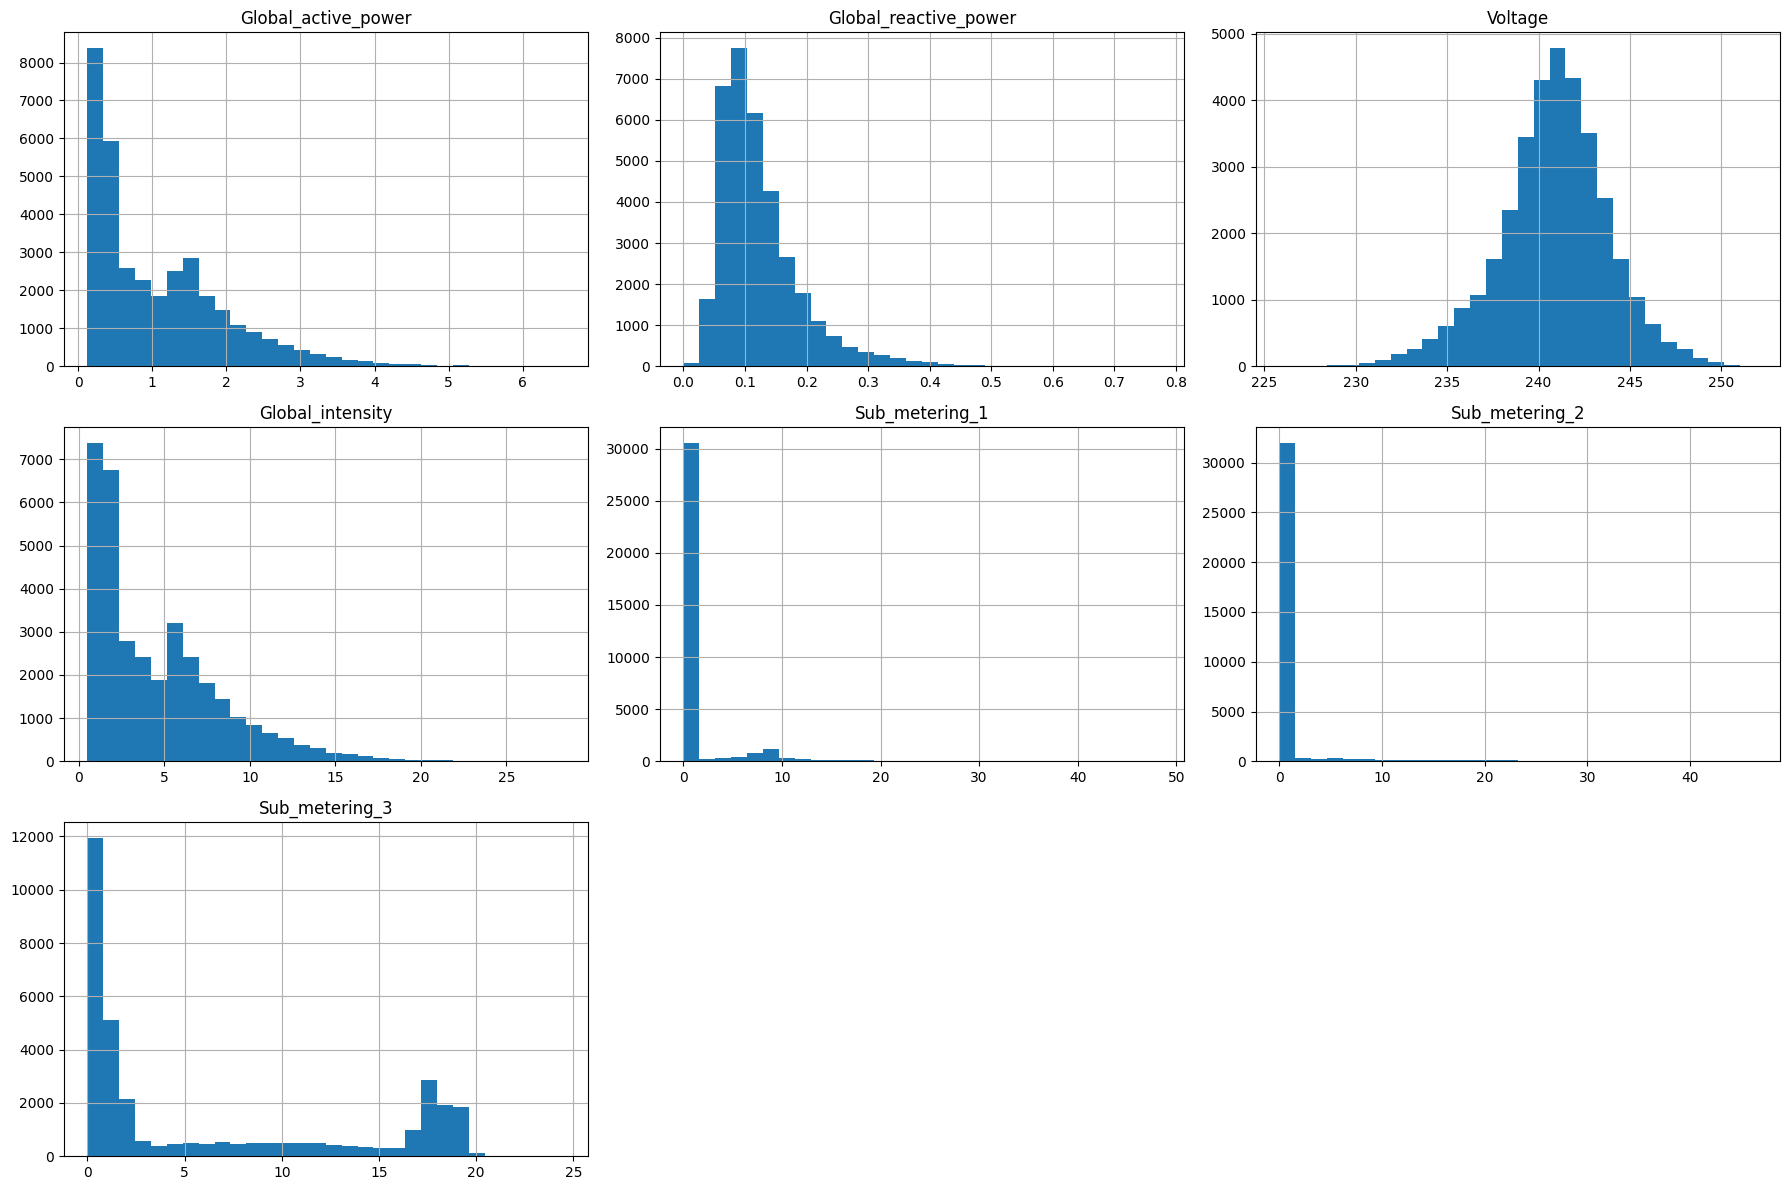

In [85]:
# Plot histograms for all numeric features in the dataset.
# Histograms help visualize the distribution of each variable,
# including its central tendency, spread, skewness, and potential outliers.

df_hourly[numeric_cols].hist(
    figsize=(18,12),
    bins=30
)

# Adjust subplot spacing to prevent overlapping labels and titles.
plt.tight_layout()

# Display the histograms.
plt.show()

### Feature Scaling

In [86]:
from sklearn.preprocessing import RobustScaler


# Initialize the scaler
scaler = RobustScaler()

# Scale all numerical columns
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_hourly),
    columns=df_hourly.columns,
    index=df_hourly.index
)

# Display the first few rows
df_scaled.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,2.767058,1.702841,-1.803212,2.885321,0.0,0.299145,1.132341
2006-12-16 18:00:00,2.289090,-0.378668,-1.821362,2.393840,0.0,9.820513,1.132754
2006-12-16 19:00:00,2.101389,-0.306008,-2.205222,2.178244,0.0,1.692308,1.119107
2006-12-16 20:00:00,1.994848,-0.447601,-1.966247,2.062910,0.0,-0.512821,1.126551
2006-12-16 21:00:00,1.823223,-0.425710,-1.086921,1.891874,0.0,0.128205,1.158809


RobustScaler() scales the data using the median and interquartile range:

* Median becomes approximately 0.
* Values are scaled relative to the spread of the middle 50% of the data.
* Outliers have much less influence on the scaling

# Dimensionality Reduction

#### 1. PCA





 PCA will be used to:

* Reduce the dimensionality of the electrical variables.
* Remove redundant information.
* Visualize the data in two dimensions.
* Provide input for the clustering algorithms (K-Means, Hierarchical, and GMM).

In [ ]:
# Fit PCA
from sklearn.decomposition import PCA
pca = PCA()

# Fit PCA on the scaled dataset
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Eplained variance ratio


In [ ]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Create a DataFrame
variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.738211,0.738211
1,PC2,0.220663,0.958874
2,PC3,0.017332,0.976206
3,PC4,0.012819,0.989025
4,PC5,0.009191,0.998216
5,PC6,0.001781,0.999998
6,PC7,0.000002,1.000000


### Plot the explained variance ratio

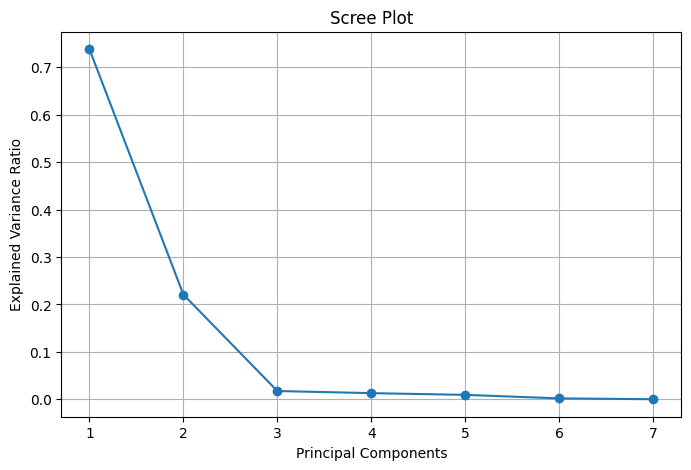

In [127]:
# Create a scree plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o',
    linestyle='-'
)

# Label the axes
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

# Add a title
plt.title("Scree Plot")

# Display ticks for each principal component
plt.xticks(range(1, len(explained_variance) + 1))

# Add grid lines for easier interpretation
plt.grid(True)

# Display the plot
plt.show()

Keep enough components to explain 95% of the variance.

In [90]:
# PCA retaining 95% variance
pca = PCA(n_components=0.95)

pca_data = pca.fit_transform(df_scaled)

print("Original Features:", df_scaled.shape[1])
print("Reduced Features:", pca_data.shape[1])

Original Features: 7
Reduced Features: 2


### Create PCA DataFrame

In [91]:
pca_columns = [f"PC{i+1}" for i in range(pca_data.shape[1])]

df_pca = pd.DataFrame(
    pca_data,
    columns=pca_columns,
    index=df_scaled.index
)

df_pca.head()

,PC1,PC2
datetime,,
2006-12-16 17:00:00,-0.876668,-0.245135
2006-12-16 18:00:00,8.425825,-1.545101
2006-12-16 19:00:00,0.358216,-0.668996
2006-12-16 20:00:00,-1.850992,-0.471019
2006-12-16 21:00:00,-1.253416,-0.612955


### PCA Loadings

This shows which original variables contribute most to each principal component.

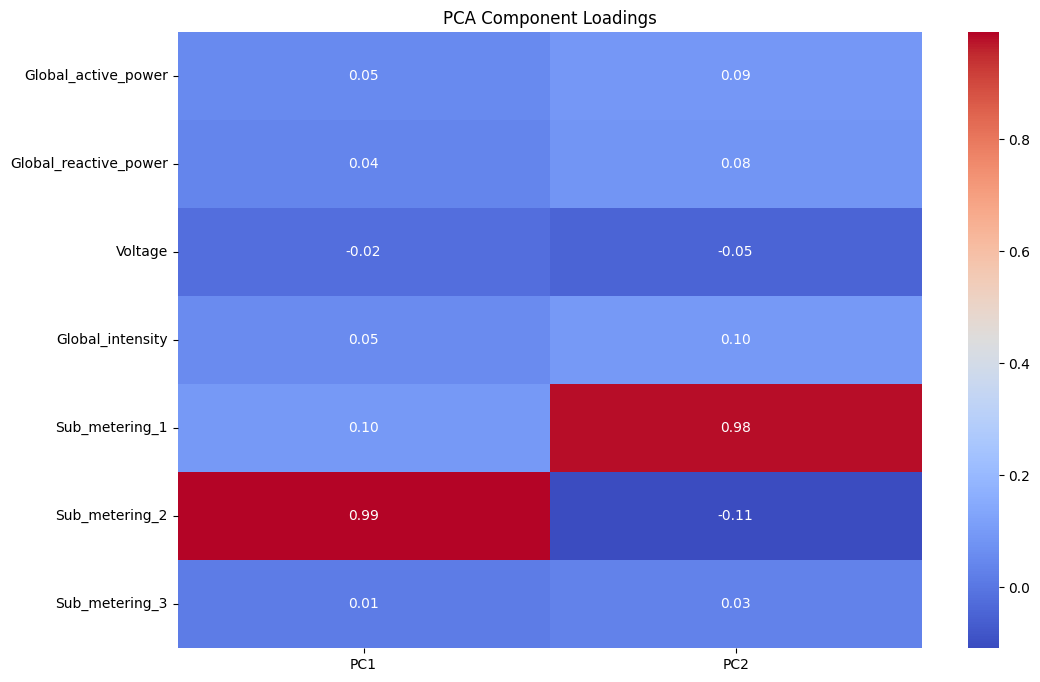

In [92]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=df_pca.columns,
    index=df_scaled.columns
)

loadings
# Visualize Loadings
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    loadings,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("PCA Component Loadings")

plt.show()

## PCA Scatter Plot

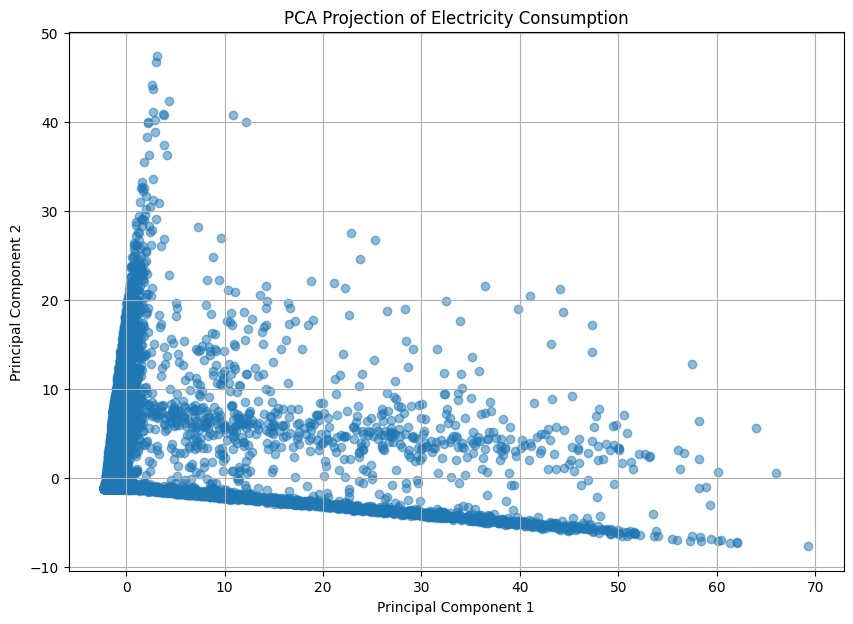

In [93]:
plt.figure(figsize=(10,7))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Electricity Consumption")

plt.grid(True)

plt.show()

## Interpretation of PCA Results

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the household electricity consumption dataset while preserving most of the information contained in the original variables.

The explained variance plot shows the proportion of variance captured by each principal component. Components explaining approximately 95% of the total variance were retained, reducing the number of features while minimizing information loss.

The PCA loadings indicate how strongly each original feature contributes to the principal components. Variables with larger absolute loading values have greater influence on the corresponding component.

The scatter plot of the first two principal components provides a lower-dimensional representation of the dataset and offers an initial visualization of potential natural groupings. These principal components will serve as inputs to the clustering algorithms in the next stage of the project.

## Apply Kernel PCA

### Kernel PCA captures nonlinear relationships, which may reveal cluster structures that PCA cannot.

In [94]:
from sklearn.decomposition import KernelPCA
# Apply Kernel PCA
kpca = KernelPCA(
    n_components=2,
    kernel='rbf',
    gamma=15,
    random_state=42
)

kernel_pca_data = kpca.fit_transform(df_scaled)

### Create a DataFrame

In [95]:
df_kernel_pca = pd.DataFrame(
    kernel_pca_data,
    columns=['KPC1', 'KPC2'],
    index=df_scaled.index
)

df_kernel_pca.head()

,KPC1,KPC2
datetime,,
2006-12-16 17:00:00,-0.026646,0.001895
2006-12-16 18:00:00,-0.026646,0.001895
2006-12-16 19:00:00,-0.026646,0.001895
2006-12-16 20:00:00,-0.026704,0.001900
2006-12-16 21:00:00,-0.026744,0.001903


### Step 4: Visualize the Kernel PCA Projection

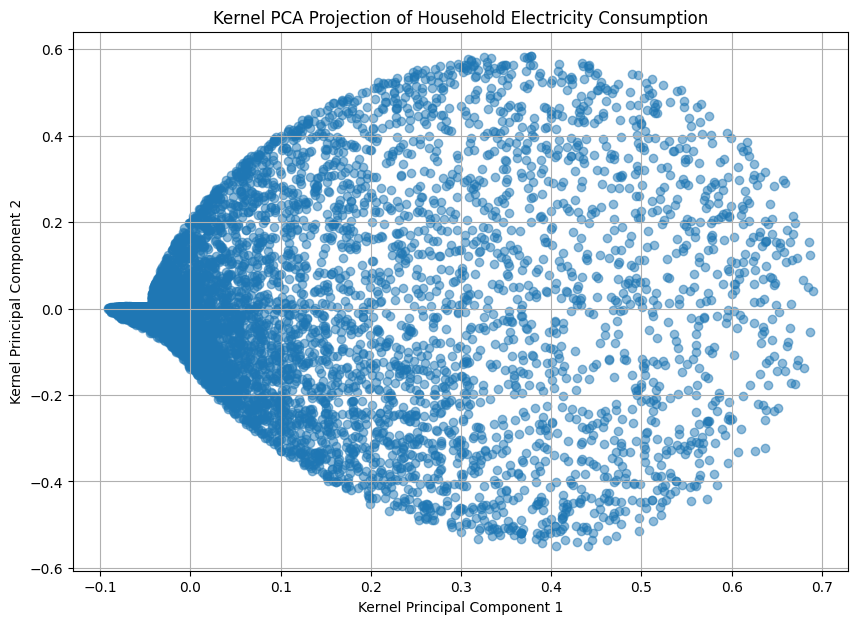

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    df_kernel_pca['KPC1'],
    df_kernel_pca['KPC2'],
    alpha=0.5
)

plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")
plt.title("Kernel PCA Projection of Household Electricity Consumption")

plt.grid(True)

plt.show()

### Compare PCA and Kernel PCA

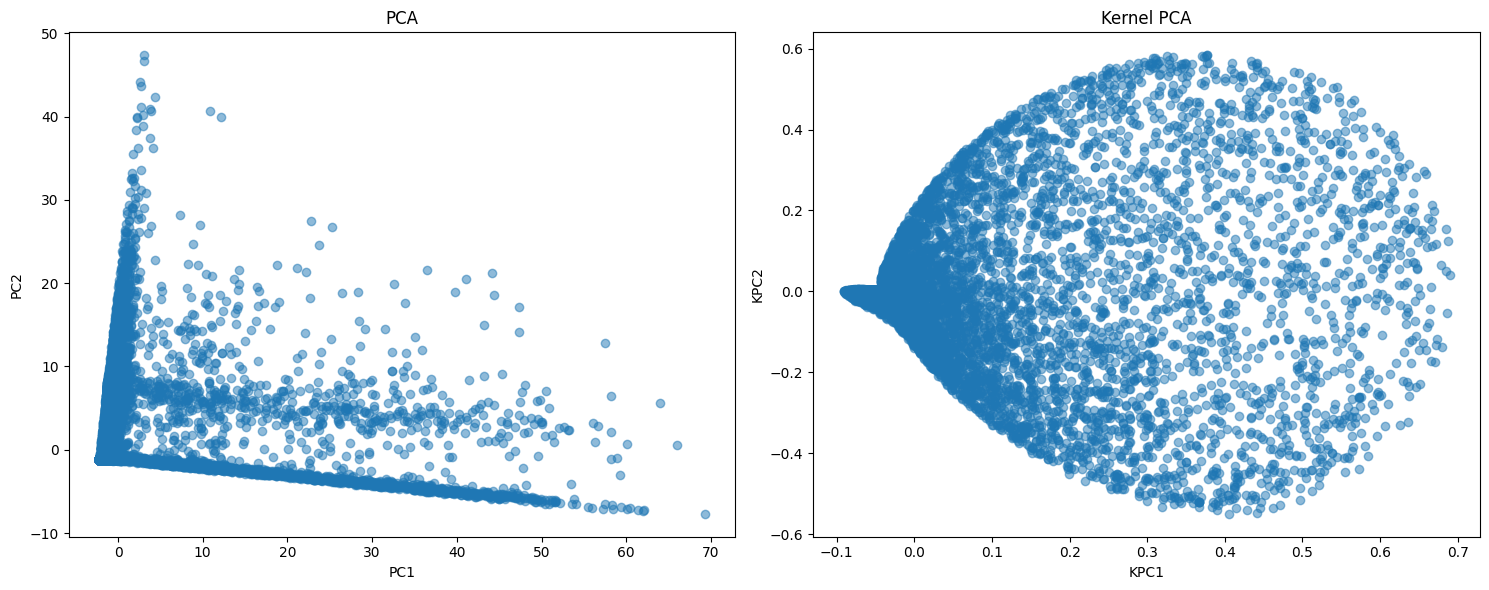

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(15,6))

# PCA
ax[0].scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    alpha=0.5
)

ax[0].set_title("PCA")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# Kernel PCA
ax[1].scatter(
    df_kernel_pca['KPC1'],
    df_kernel_pca['KPC2'],
    alpha=0.5
)

ax[1].set_title("Kernel PCA")
ax[1].set_xlabel("KPC1")
ax[1].set_ylabel("KPC2")

plt.tight_layout()
plt.show()

## Interpretation of Kernel PCA

Kernel Principal Component Analysis (Kernel PCA) was applied using the Radial Basis Function (RBF) kernel to capture nonlinear relationships among the household electricity consumption variables.

Unlike standard PCA, which identifies linear combinations of the original features, Kernel PCA projects the data into a higher-dimensional feature space before performing dimensionality reduction. This enables the detection of more complex structures that may not be visible using linear PCA.

The two-dimensional projection produced by Kernel PCA will be used in the subsequent clustering analysis to determine whether nonlinear feature extraction improves the separation of natural electricity consumption patterns.



Because the objective of the project is to identify natural consumption clusters before forecasting, the Kernel PCA representation was selected as the input for subsequent clustering algorithms (K-Means, Hierarchical Clustering, and Gaussian Mixture Models)

# Clustering
Clusturing  will help in discover patterns or groups in electricity consumption that is identify different consumption patterns (for example, low-, medium-, and high-usage regimes), and then  build predictive models.

### Import Libraries

In [98]:

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score
)


#### Elbow Method (K-Means)

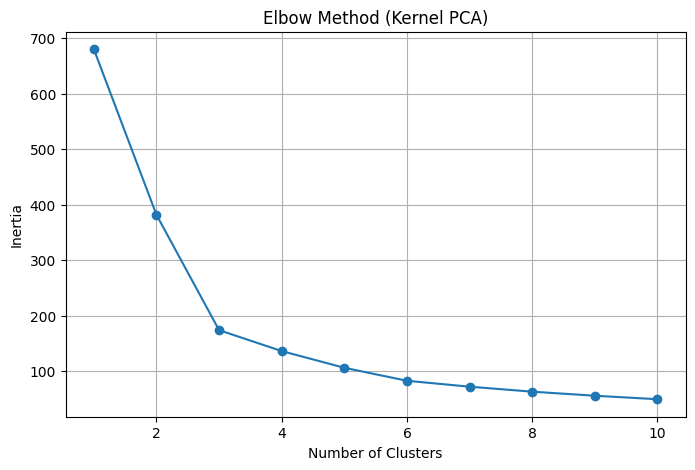

In [ ]:
# Create an empty list to store the inertia (Within-Cluster Sum of Squares)
# for each value of K (number of clusters)
inertia = []

K = range(1, 11)

for k in K:
    model = KMeans(  # Initialize the K-Means clustering mode
        n_clusters=k, # Number of clusters to form
        random_state=42,  # Ensures reproducibility of results
        n_init=10 # Run K-Means 10 times
    )

    model.fit(df_kernel_pca)  # Fit the K-Means model to the Kernel PCA-transformed dataset
  # Store the inertia (Within-Cluster Sum of Squares) for the current K
    # Lower inertia indicates that data points are closer to their assigned cluster centroids.
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method (Kernel PCA)")

plt.grid(True)

plt.show()

The point where the curve begins to flatten is referred to as the elbow. In this plot, the elbow occurs at K = 3, indicating that three clusters provide a good balance between minimizing within-cluster variation and avoiding unnecessary model complexity. 

#### Silhouette Analysis

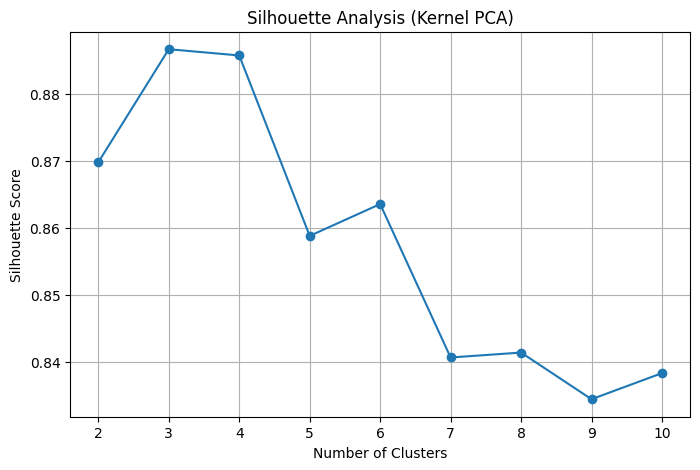

In [100]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(df_kernel_pca)

    score = silhouette_score(df_kernel_pca, labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (Kernel PCA)")

plt.grid(True)

plt.show()

The silhouette analysis indicates that three clusters produce the best clustering structure. The high silhouette score suggests that observations within each cluster are highly similar while remaining well separated from observations in other clusters. As the number of clusters increases beyond three, the quality of the clustering decreases, suggesting that additional clusters unnecessarily divide naturally occurring groups.

### Build Final KMeans Model

Replace 3 with the optimal number determined from the Elbow and Silhouette analyses.

In [129]:
# K-MEANS CLUSTERING

# Create K-Means model with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit model and generate cluster labels
kmeans_labels = kmeans.fit_predict(df_kernel_pca)

# Evaluate clustering performance
print(
    "Silhouette Score:",
    silhouette_score(
        df_kernel_pca,
        kmeans_labels
    )
)

print(
    "Calinski-Harabasz Score:",
    calinski_harabasz_score(
        df_kernel_pca,
        kmeans_labels
    )
)

print(
    "Davies-Bouldin Score:",
    davies_bouldin_score(
        df_kernel_pca,
        kmeans_labels
    )
)

# VISUALIZATION OF CLUSTERS

# Create a copy of the Kernel PCA DataFrame
cluster_df = df_kernel_pca.copy()

# Add the cluster labels
cluster_df["Cluster"] = kmeans_labels

# Display the first few rows
cluster_df.head()

Silhouette Score: 0.8866766659012649
Calinski-Harabasz Score: 50228.92826211459
Davies-Bouldin Score: 0.624433576848277


,KPC1,KPC2,Cluster
datetime,,,
2006-12-16 17:00:00,-0.026646,0.001895,0
2006-12-16 18:00:00,-0.026646,0.001895,0
2006-12-16 19:00:00,-0.026646,0.001895,0
2006-12-16 20:00:00,-0.026704,0.001900,0
2006-12-16 21:00:00,-0.026744,0.001903,0


#### **The Silhouette Score evaluates two characteristics:**

* Cohesion: How close observations are to other points in the same cluster.
* Separation: How far observations are from points in other clusters.

The Silhouette Score of 0.8867 is very close to 1, indicating that the clusters are highly cohesive and well separated.

#### **The Calinski-Harabasz Index compares:**

* Between-cluster variance (how far apart the clusters are)
* Within-cluster variance (how compact each cluster is)

A score of 50,228.93 is  high, indicating that:
* the clusters are very compact,
* the clusters are well separated,
* there is a clear clustering structure within the data

#### **The Davies-Bouldin Index measures:**
* how similar clusters are to one another,
* how dispersed each cluster is.

The score of 0.6244 is well below 1, indicating that the clusters are compact and clearly separated. This means that each cluster is internally consistent while remaining distinct from the others, with relatively little overlap.

### Visualize KMeans

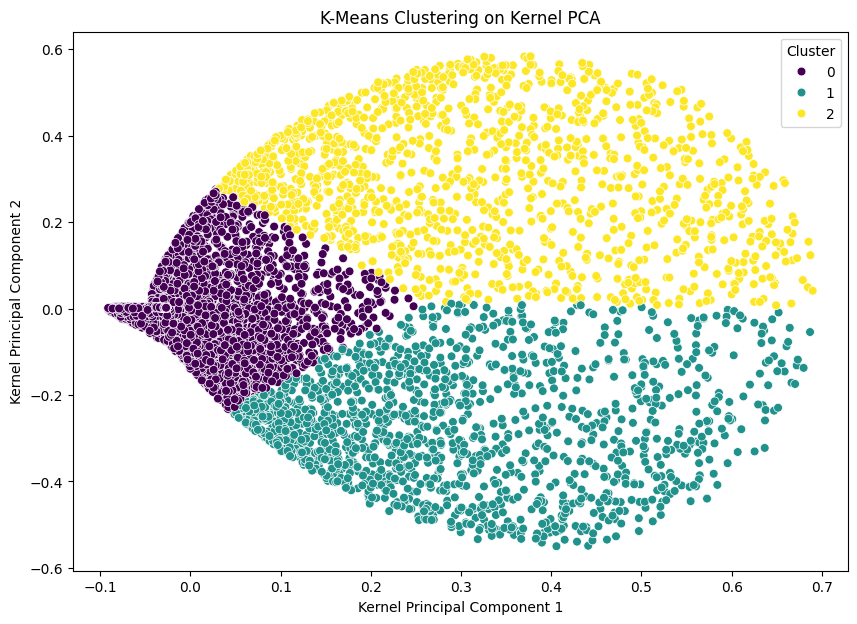

In [103]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_kernel_pca,
    x="KPC1",
    y="KPC2",
    hue=kmeans_labels,
    palette="viridis",
    s=40
)

plt.title("K-Means Clustering on Kernel PCA")
plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")

plt.legend(title="Cluster")

plt.show()

### Hierarchical Clustering

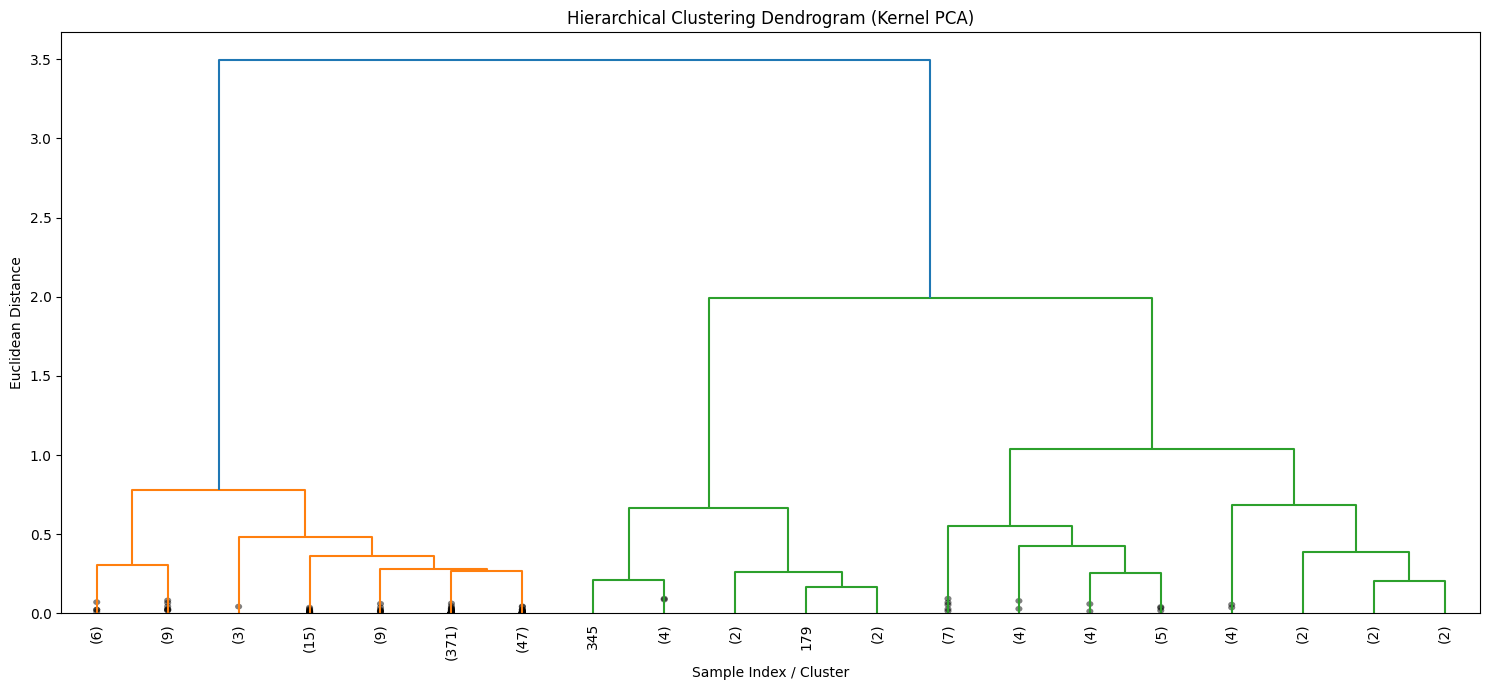

In [131]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# HIERARCHICAL (AGGLOMERATIVE) CLUSTERING

# Create the Agglomerative Clustering model with 3 clusters
hierarchical = AgglomerativeClustering(
    n_clusters=3,     # Number of clusters to form
    linkage='ward'    # Ward's method minimizes the variance within clusters
)

# Fit the model and generate cluster labels
hierarchical_labels = hierarchical.fit_predict(df_kernel_pca)

# Randomly sample 500 observations to improve dendrogram readability
# (Using the entire dataset would produce a cluttered dendrogram)
sample = df_kernel_pca.sample(n=500, random_state=42)

# Compute the hierarchical linkage matrix using Ward's method
linked = linkage(
    sample.values,
    method='ward'
)

# Create the dendrogram
plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode='lastp',   # Display only the last merged clusters
    p=20,                    # Show the last 20 merged clusters
    leaf_rotation=90,        # Rotate leaf labels for readability
    leaf_font_size=10,       # Set font size of leaf labels
    show_contracted=True     # Show the sizes of hidden clusters
)

# Add plot title and axis labels
plt.title("Hierarchical Clustering Dendrogram (Kernel PCA)")
plt.xlabel("Sample Index / Cluster")
plt.ylabel("Euclidean Distance")

# Adjust spacing to prevent overlapping labels
plt.tight_layout()

# Display the dendrogram
plt.show()

### Evaluate Hierarchical Clustering

In [106]:
print("Silhouette Score:",
      silhouette_score(df_kernel_pca, hierarchical_labels))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(df_kernel_pca, hierarchical_labels))

print("Davies-Bouldin Score:",
      davies_bouldin_score(df_kernel_pca, hierarchical_labels))

Silhouette Score: 0.8696345262473653
Calinski-Harabasz Score: 38882.21786679838
Davies-Bouldin Score: 0.7720825475825194


A Silhouette Score of 0.8696 indicates that the clusters are highly cohesive and well separated. Most observations are much closer to the observations within their own cluster than to those in neighboring clusters, suggesting that the hierarchical clustering algorithm successfully identified distinct groups within the Kernel PCA-transformed dataset.

The Calinski-Harabasz Score of 38,882.22 is very high, indicating that the clusters are compact and clearly separated. Although this value is lower than the score obtained from K-Means, it still reflects a strong clustering structure within the dataset.

The Davies-Bouldin Score of 0.7721 is well below 1, indicating that the clusters are well separated and internally consistent. This suggests that there is relatively little overlap between clusters, confirming the effectiveness of the hierarchical clustering model

#### Visualize Hierarchical Clustering

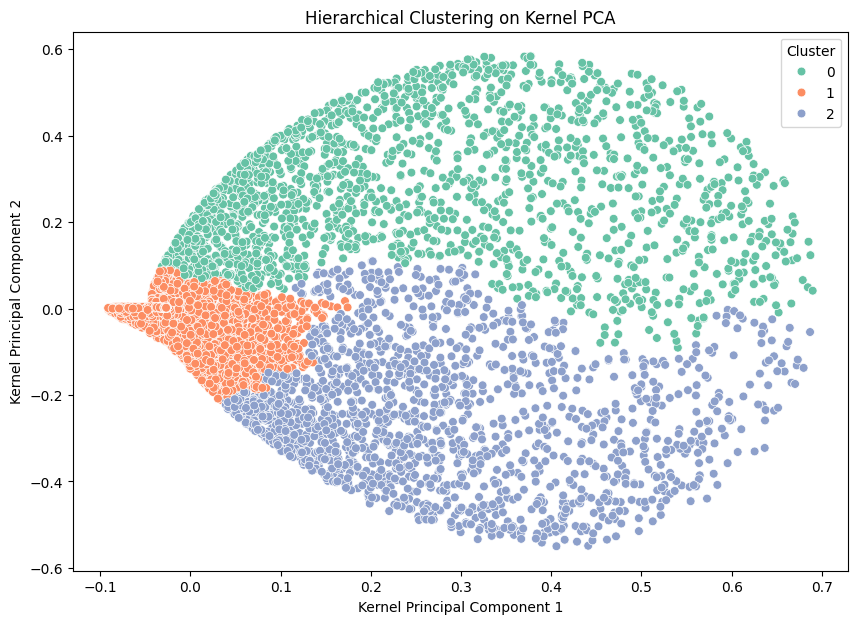

In [107]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_kernel_pca,
    x="KPC1",
    y="KPC2",
    hue=hierarchical_labels,
    palette="Set2",
    s=40
)

plt.title("Hierarchical Clustering on Kernel PCA")
plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")

plt.legend(title="Cluster")

plt.show()

## Gaussian Mixture Model

In [108]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm_labels = gmm.fit_predict(df_kernel_pca)

### Evaluate GMM

In [109]:
print("Silhouette Score:",
      silhouette_score(df_kernel_pca, gmm_labels))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(df_kernel_pca, gmm_labels))

print("Davies-Bouldin Score:",
      davies_bouldin_score(df_kernel_pca, gmm_labels))

Silhouette Score: 0.542477419805695
Calinski-Harabasz Score: 6353.2589570030495
Davies-Bouldin Score: 1.3740530577234686


### Visualize GMM

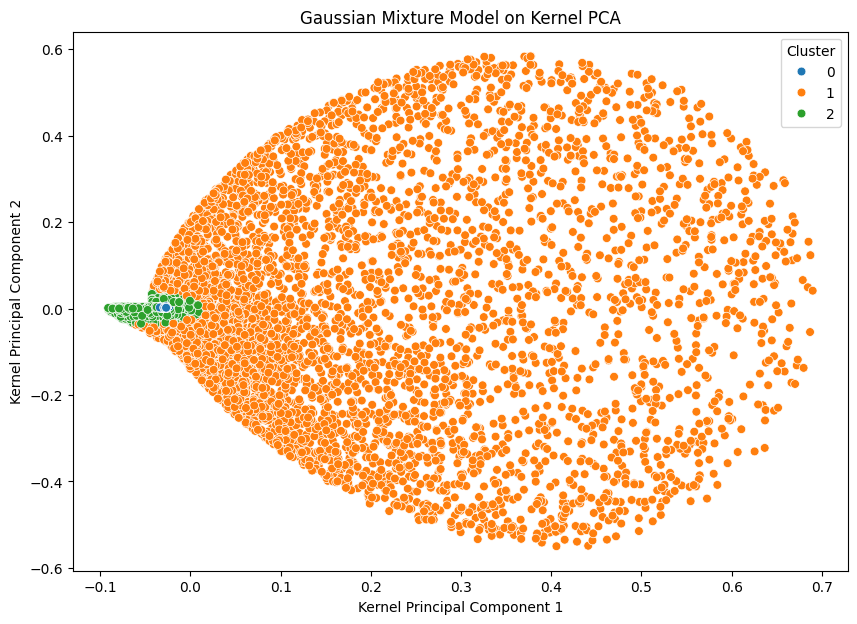

In [110]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_kernel_pca,
    x="KPC1",
    y="KPC2",
    hue=gmm_labels,
    palette="tab10",
    s=40
)

plt.title("Gaussian Mixture Model on Kernel PCA")
plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")

plt.legend(title="Cluster")

plt.show()

### Compare the Three Models

In [111]:
comparison = pd.DataFrame({

    "Model":[
        "K-Means",
        "Hierarchical",
        "Gaussian Mixture"
    ],

    "Silhouette Score":[
        silhouette_score(df_kernel_pca,kmeans_labels),
        silhouette_score(df_kernel_pca,hierarchical_labels),
        silhouette_score(df_kernel_pca,gmm_labels)
    ],

    "Calinski-Harabasz":[
        calinski_harabasz_score(df_kernel_pca,kmeans_labels),
        calinski_harabasz_score(df_kernel_pca,hierarchical_labels),
        calinski_harabasz_score(df_kernel_pca,gmm_labels)
    ],

    "Davies-Bouldin":[
        davies_bouldin_score(df_kernel_pca,kmeans_labels),
        davies_bouldin_score(df_kernel_pca,hierarchical_labels),
        davies_bouldin_score(df_kernel_pca,gmm_labels)
    ]

})

comparison.sort_values(
    by="Silhouette Score",
    ascending=False
)

,Model,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.886677,50228.928262,0.624434
1,Hierarchical,0.869635,38882.217867,0.772083
2,Gaussian Mixture,0.542477,6353.258957,1.374053


#### **Model to choose will be based on which clustring model:**

* Achieved the highest Silhouette Score, indicating the best balance of cluster cohesion and separation.
* Produced the highest Calinski-Harabasz Score, indicating the strongest ratio of between-cluster to within-cluster variance.
* Recorded the lowest Davies-Bouldin Score, indicating the least overlap and the most compact clusters.

Therefore, K-Means is selected as the final clustering algorithm for this study.

#### Assign the Best Cluster Labels



In [112]:
df_hourly = df_hourly.iloc[:len(kmeans_labels)].copy()

df_hourly["Cluster"] = kmeans_labels

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Cluster
datetime,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,0


### Check Cluster Sizes

In [113]:
cluster_counts = (
    df_hourly["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    31776
1     1484
2     1329
Name: count, dtype: int64

#### Interpret the Clusters

In [114]:
cluster_summary = (
    df_hourly
    .groupby("Cluster")
    .agg({
        "Global_active_power":["mean","std"],
        "Voltage":"mean",
        "Global_intensity":"mean",
        "Sub_metering_1":"mean",
        "Sub_metering_2":"mean",
        "Sub_metering_3":"mean"
    })
)

cluster_summary

Global_active_power               Voltage Global_intensity  \
                       mean       std        mean             mean   
Cluster                                                              
0                  1.159201  0.900958  240.688270         4.911750   
1                  0.302677  0.083055  241.487044         1.316573   
2                  0.322683  0.070551  243.554854         1.375064   

        Sub_metering_1 Sub_metering_2 Sub_metering_3  
                  mean           mean           mean  
Cluster                                               
0             1.207644       1.401405       6.955267  
1             0.000022       0.024461       0.815274  
2             0.000251       0.018259       0.461462

profile the clusters that were created by K-Means algorithm that is to understand what makes each cluster different. This table summarizes the average characteristics of each cluster so you can interpret what each cluster represents (e.g., low, medium, or high electricity consumption).

This table profiles the three clusters identified by K-Means. By comparing the average values of the electricity consumption variables, we can assign meaningful descriptions to each cluster.

| **Cluster** | **Interpretation** |
|--------------|--------------------|
| **Cluster 0** | High electricity consumption |
| **Cluster 1** | Low electricity consumption |
| **Cluster 2** | Low electricity consumption with slightly higher voltage |

### Name the clusters

Extracting the average Global Active Power for each cluster and then sorting the clusters from the lowest to the highest average electricity consumption to identify which clusters represent low, medium, or high consumption.

In [115]:
cluster_power = (
    df_hourly
    .groupby("Cluster")["Global_active_power"]
    .mean()
    .sort_values()
)

print(cluster_power)

Cluster
1    0.302677
2    0.322683
0    1.159201
Name: Global_active_power, dtype: float64


In [132]:
# Map cluster labels to descriptive names
cluster_mapping = {
    0: "High",
    1: "Low",
    2: "Low (High Voltage)"
}

df_hourly["Consumption_Regime"] = (
    df_hourly["Cluster"]
    .map(cluster_mapping)
)

In [134]:
df_hourly[["Cluster","Consumption_Regime"]]

,Cluster,Consumption_Regime
datetime,,
2006-12-17 17:00:00,0,High
2006-12-17 18:00:00,0,High
2006-12-17 19:00:00,0,High
2006-12-17 20:00:00,0,High
2006-12-17 21:00:00,0,High
...,...,...
2010-11-26 17:00:00,0,High
2010-11-26 18:00:00,0,High
2010-11-26 19:00:00,0,High


# Forecasting

The objective now is to predict: 

Global Active Power using historical electricity consumption data.

In [136]:
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Cluster,Consumption_Regime,Cluster_Label,Hour,Day,Month,DayOfWeek,lag1,lag2,lag3,lag24,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,0,High,2,17,17,12,6,3.326033,2.985400,2.092633,4.222889,2.465140,0.752521
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,0,High,2,18,17,12,6,3.406767,3.326033,2.985400,3.632200,2.467844,0.757001
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,0,High,2,19,17,12,6,3.697100,3.406767,3.326033,3.400233,2.447351,0.737057
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,0,High,2,20,17,12,6,2.908400,3.697100,3.406767,3.268567,2.451224,0.741788
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,0,High,2,21,17,12,6,3.361500,2.908400,3.697100,3.056467,2.450569,0.741237


### Encode the Cluster Labels
This converts the categorical consumption regimes into numeric values that machine learning models can use.

In [137]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_hourly["Cluster_Label"] = encoder.fit_transform(
    df_hourly["Consumption_Regime"]
)

### Create Time Features

In [119]:
df_hourly["Hour"] = df_hourly.index.hour
df_hourly["Day"] = df_hourly.index.day
df_hourly["Month"] = df_hourly.index.month
df_hourly["DayOfWeek"] = df_hourly.index.dayofweek

These features help the model learn seasonal patterns such as:

* Hour of the day
* Day of the month
* Month of the year
* Day of the week

Electricity consumption often follows these time-based patterns.

### Create Lag Features
Forecasting requires previous observations.

In [120]:
target = "Global_active_power"

df_hourly["lag1"] = df_hourly[target].shift(1)
df_hourly["lag2"] = df_hourly[target].shift(2)
df_hourly["lag3"] = df_hourly[target].shift(3)
df_hourly["lag24"] = df_hourly[target].shift(24)

### Remove Missing Values

The lag features introduce missing values at the beginning of the dataset because there are no previous observations for the first few rows.

In [138]:
# Remove rows containing missing values created by lag features
df_forecast = df_hourly.dropna().copy()

# Check the dataset dimensions
print(df_forecast.shape)

# Verify that no missing values remain
print(df_forecast.isnull().sum())

(34565, 20)
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Cluster                  0
Consumption_Regime       0
Cluster_Label            0
Hour                     0
Day                      0
Month                    0
DayOfWeek                0
lag1                     0
lag2                     0
lag3                     0
lag24                    0
rolling_mean_24          0
rolling_std_24           0
dtype: int64


### Train-Test Split

In [ ]:
# Determine the split index (80% training, 20% testing)
split_index = int(len(X) * 0.8)

# Split the features
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# Split the target
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Display the shapes of the datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

In [124]:
split = int(len(df_hourly) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

#### Scale the inputs

In [125]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Model forecasting

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    SimpleRNN,
    LSTM,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

### Artificial Neural Network (ANN)
Build the Model

In [ ]:
ann = Sequential([

    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(1)

])

ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

ann.summary()

Train

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_ann = ann.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)


### Predict

In [ ]:
ann_predictions = ann.predict(X_test).flatten()

#### Evaluate

In [ ]:
ann_mae = mean_absolute_error(y_test, ann_predictions)

ann_rmse = np.sqrt(
    mean_squared_error(y_test, ann_predictions)
)

ann_r2 = r2_score(
    y_test,
    ann_predictions
)

print("ANN")

print("MAE :", ann_mae)

print("RMSE:", ann_rmse)

print("R2 :", ann_r2)

3. Prepare Data for RNN/LSTM


In [ ]:

# RNNs require a 3-dimensional input.

X_train_rnn = X_train.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

X_test_rnn = X_test.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)


4. Simple RNN


 Build

In [ ]:

rnn = Sequential([

    SimpleRNN(

        64,

        activation='tanh',

        input_shape=(1, X_train.shape[1])

    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)

])

rnn.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

rnn.summary()


In [ ]:
# Train
history_rnn = rnn.fit(

    X_train_rnn,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)


In [ ]:
# Predict
rnn_predictions = rnn.predict(X_test_rnn).flatten()


In [ ]:
# Evaluate
rnn_mae = mean_absolute_error(
    y_test,
    rnn_predictions
)

rnn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rnn_predictions
    )
)

rnn_r2 = r2_score(
    y_test,
    rnn_predictions
)

print("RNN")

print("MAE :", rnn_mae)

print("RMSE:", rnn_rmse)

print("R2 :", rnn_r2)


5. LSTM

Build


In [ ]:
lstm = Sequential([

    LSTM(

        64,

        input_shape=(1, X_train.shape[1])

    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)

])

lstm.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

lstm.summary()


In [ ]:
# Train
history_lstm = lstm.fit(

    X_train_rnn,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)


In [ ]:
# Predict
lstm_predictions = lstm.predict(
    X_test_rnn
).flatten()


In [ ]:
# Evaluate
lstm_mae = mean_absolute_error(
    y_test,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lstm_predictions
    )
)

lstm_r2 = r2_score(
    y_test,
    lstm_predictions
)

print("LSTM")

print("MAE :", lstm_mae)

print("RMSE:", lstm_rmse)

print("R2 :", lstm_r2)


6. Compare Models


In [ ]:
results = pd.DataFrame({

    "Model":[

        "ANN",

        "RNN",

        "LSTM"

    ],

    "MAE":[

        ann_mae,

        rnn_mae,

        lstm_mae

    ],

    "RMSE":[

        ann_rmse,

        rnn_rmse,

        lstm_rmse

    ],

    "R2":[

        ann_r2,

        rnn_r2,

        lstm_r2

    ]

})

results.sort_values(
    by="RMSE"
)


7. Visualize Results


In [ ]:


plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Model Comparison Using RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()


8. Plot Actual vs Predicted (Best Model)

If LSTM performs best:


In [ ]:

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    lstm_predictions,
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Household Power Consumption")

plt.show()